# Heart Disease Prediction — Comprehensive Model Comparison
> Covers: Bagging, Boosting (AdaBoost, GBM, HistGBM), Stacking, Voting, Extra Trees, SVM, KNN and more

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.impute import KNNImputer

# Individual models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier,
    VotingClassifier, StackingClassifier
)

## 1. Data Loading & Preprocessing

In [2]:
df = pd.read_csv("heart.csv")
print(f"Shape: {df.shape}")

# LabelEncoder for all categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Impute physiologically impossible 0s
df['Cholesterol'].replace(0, np.nan, inplace=True)
df['RestingBP'].replace(0, np.nan, inplace=True)
df_imp = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(df), columns=df.columns)
print(f"Missing after imputation: {df_imp.isnull().sum().sum()}")

Shape: (918, 12)
Missing after imputation: 0


## 2. Feature Engineering

In [3]:
df_imp['Age_MaxHR_ratio'] = df_imp['Age'] / (df_imp['MaxHR'] + 1)
df_imp['BP_Chol_ratio']   = df_imp['RestingBP'] / (df_imp['Cholesterol'] + 1)
df_imp['OldpeakAbs']      = df_imp['Oldpeak'].abs()
print("Features:", list(df_imp.columns))

Features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Age_MaxHR_ratio', 'BP_Chol_ratio', 'OldpeakAbs']


## 3. Train/Test Split & Scaling

In [4]:
X = df_imp.drop(columns='HeartDisease')
Y = df_imp['HeartDisease']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, random_state=42, test_size=0.2, stratify=Y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (734, 14) | Test: (184, 14)


## 4. All Models — Full Comparison
### Individual Models

In [5]:
results = {}

# ── Scaled models ──────────────────────────────────────────────────────
for name, model in {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5),
    'SVM (RBF)':           SVC(kernel='rbf', C=2, probability=True),
    'SVM (Linear)':        SVC(kernel='linear', C=1, probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':         GaussianNB(),
}.items():
    model.fit(X_train_sc, Y_train)
    results[name] = accuracy_score(Y_test, model.predict(X_test_sc))
    print(f"{name:<25} {results[name]:.4f}")

Logistic Regression       0.8478
SVM (RBF)                 0.8750
SVM (Linear)              0.8587
KNN                       0.8967
Naive Bayes               0.8641


### Bagging Models

In [6]:
for name, model in {
    'Decision Tree':  DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=2, random_state=42),
    'Extra Trees':    ExtraTreesClassifier(n_estimators=500, max_depth=8, min_samples_leaf=2, random_state=42),
    'Bagging (DT)':   BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=200, random_state=42),
}.items():
    model.fit(X_train, Y_train)
    results[name] = accuracy_score(Y_test, model.predict(X_test))
    print(f"{name:<25} {results[name]:.4f}")

Decision Tree             0.7989
Random Forest             0.8750
Extra Trees               0.8913
Bagging (DT)              0.8696


### Boosting Models
> XGBoost & LightGBM require internet to install. HistGradientBoosting is sklearn's built-in equivalent.

In [7]:
for name, model in {
    'AdaBoost (DT base)':     AdaBoostClassifier(
                                  estimator=DecisionTreeClassifier(max_depth=3),
                                  n_estimators=200, learning_rate=0.1, random_state=42),
    'AdaBoost (stump)':       AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(
                                  n_estimators=300, learning_rate=0.05,
                                  max_depth=4, subsample=0.8, random_state=42),
    'HistGradient Boosting':  HistGradientBoostingClassifier(
                                  max_iter=300, learning_rate=0.05, max_depth=4, random_state=42),
}.items():
    model.fit(X_train, Y_train)
    results[name] = accuracy_score(Y_test, model.predict(X_test))
    print(f"{name:<25} {results[name]:.4f}")

AdaBoost (DT base)        0.8804
AdaBoost (stump)          0.8804
Gradient Boosting         0.8641
HistGradient Boosting     0.8641


### Ensemble Techniques — Voting & Stacking

In [8]:
# Voting — Soft (uses predicted probabilities)
voting_soft = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, C=0.5)),
    ('svm', SVC(kernel='rbf', C=2, probability=True)),
    ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)),
], voting='soft')
voting_soft.fit(X_train_sc, Y_train)
results['Voting (soft)'] = accuracy_score(Y_test, voting_soft.predict(X_test_sc))
print(f"Voting (soft)             {results['Voting (soft)']:.4f}")

# Voting — Hard (majority vote)
voting_hard = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, C=0.5)),
    ('svm', SVC(kernel='rbf', C=2)),
    ('rf',  RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
], voting='hard')
voting_hard.fit(X_train_sc, Y_train)
results['Voting (hard)'] = accuracy_score(Y_test, voting_hard.predict(X_test_sc))
print(f"Voting (hard)             {results['Voting (hard)']:.4f}")

# Stacking — LR meta-learner (passthrough=True adds original features to meta-learner)
stack_lr = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
        ('svm', SVC(kernel='rbf', C=2, probability=True)),
        ('et',  ExtraTreesClassifier(n_estimators=300, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, passthrough=True
)
stack_lr.fit(X_train_sc, Y_train)
results['Stacking (meta=LR)'] = accuracy_score(Y_test, stack_lr.predict(X_test_sc))
print(f"Stacking (meta=LR)        {results['Stacking (meta=LR)']:.4f}")

# Stacking — GBM meta-learner
stack_gb = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, random_state=42)),
        ('svm', SVC(kernel='rbf', C=2, probability=True)),
        ('knn', KNeighborsClassifier(n_neighbors=7)),
        ('nb',  GaussianNB()),
    ],
    final_estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    cv=5
)
stack_gb.fit(X_train_sc, Y_train)
results['Stacking (meta=GBM)'] = accuracy_score(Y_test, stack_gb.predict(X_test_sc))
print(f"Stacking (meta=GBM)       {results['Stacking (meta=GBM)']:.4f}")

Voting (soft)             0.8859
Voting (hard)             0.8804
Stacking (meta=LR)        0.8804
Stacking (meta=GBM)       0.8641


## 5. Results Summary & Visualization

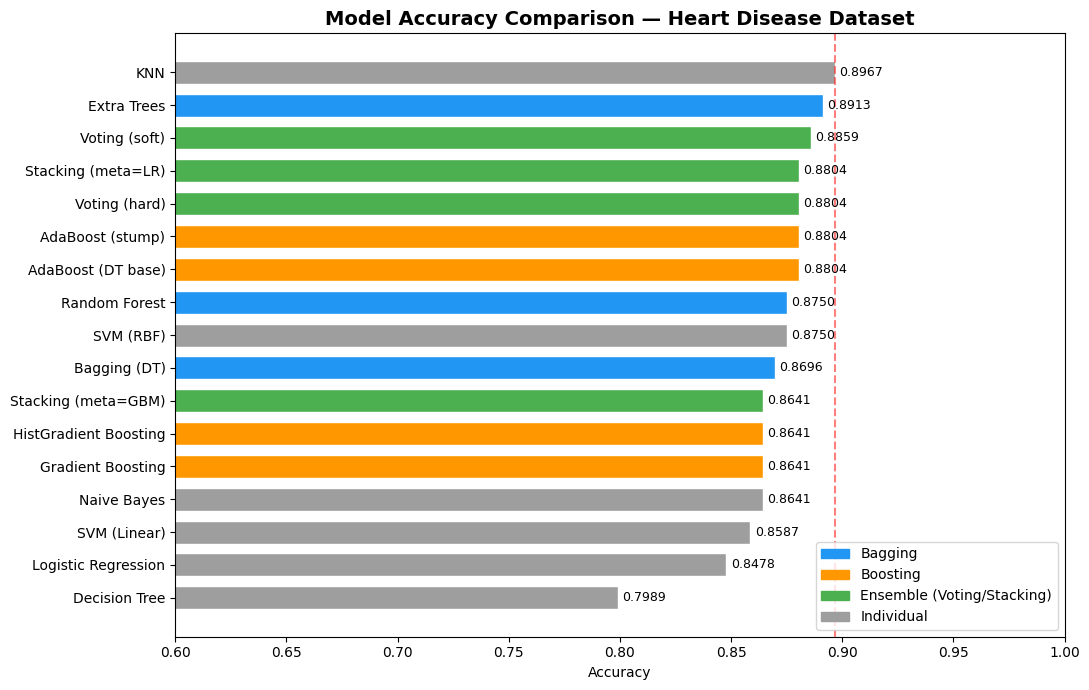


🏆 Best Model: KNN → 0.8967


In [9]:
sorted_results = dict(sorted(results.items(), key=lambda x: x[1]))
names = list(sorted_results.keys())
accs  = list(sorted_results.values())

colors = []
for n in names:
    if n in ['Extra Trees', 'Random Forest', 'Bagging (DT)']:
        colors.append('#2196F3')   # blue = bagging
    elif 'AdaBoost' in n or 'Gradient' in n or 'Hist' in n:
        colors.append('#FF9800')   # orange = boosting
    elif 'Voting' in n or 'Stacking' in n:
        colors.append('#4CAF50')   # green = ensemble
    else:
        colors.append('#9E9E9E')   # grey = individual

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(names, accs, color=colors, edgecolor='white', height=0.7)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=9)
ax.set_xlim(0.6, 1.0)
ax.axvline(x=max(accs), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(accs):.4f}')
ax.set_title('Model Accuracy Comparison — Heart Disease Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy')

from matplotlib.patches import Patch
legend = [Patch(color='#2196F3', label='Bagging'),
          Patch(color='#FF9800', label='Boosting'),
          Patch(color='#4CAF50', label='Ensemble (Voting/Stacking)'),
          Patch(color='#9E9E9E', label='Individual')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(f"\n🏆 Best Model: {max(results, key=results.get)} → {max(results.values()):.4f}")

## 6. Best Model — Extra Trees — Detailed Evaluation

=== Classification Report (Extra Trees) ===
               precision    recall  f1-score   support

   No Disease       0.91      0.84      0.87        82
Heart Disease       0.88      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.89      0.89       184
 weighted avg       0.89      0.89      0.89       184

10-Fold CV: 0.8571 ± 0.0560


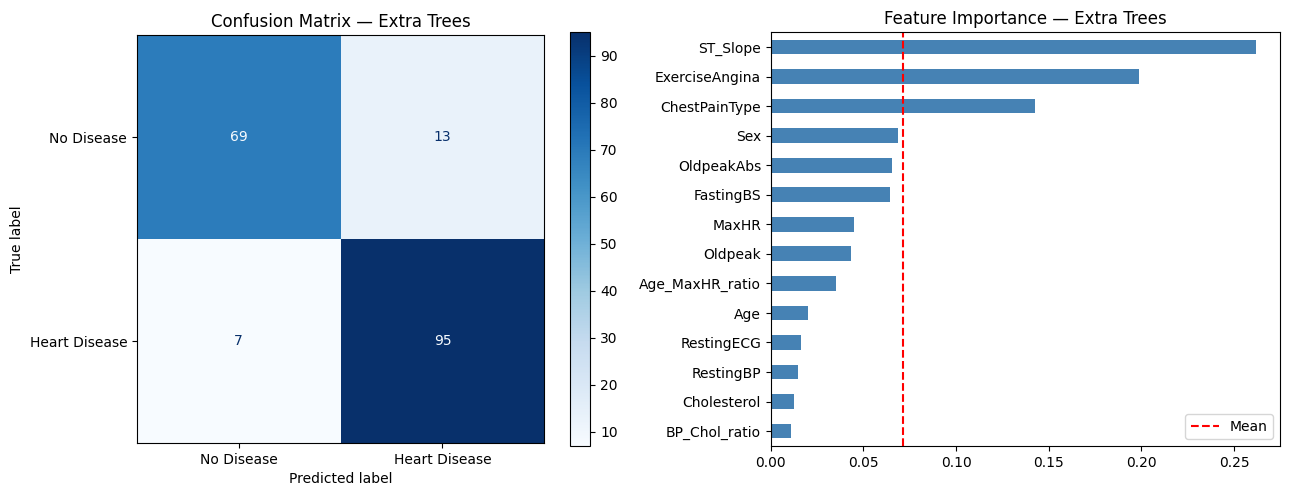

In [10]:
best_model = ExtraTreesClassifier(n_estimators=500, max_depth=8, min_samples_leaf=2, random_state=42)
best_model.fit(X_train, Y_train)
best_pred = best_model.predict(X_test)

print("=== Classification Report (Extra Trees) ===")
print(classification_report(Y_test, best_pred, target_names=['No Disease', 'Heart Disease']))

# 10-fold CV
cv = cross_val_score(best_model, X, Y, cv=10, scoring='accuracy')
print(f"10-Fold CV: {cv.mean():.4f} ± {cv.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test, best_pred,
    display_labels=['No Disease', 'Heart Disease'], cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix — Extra Trees')

# Feature importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — Extra Trees')
axes[1].axvline(feat_imp.mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import joblib, os

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Train & Save raw models (no scaling needed) ──────────────────
raw_models = {
    "decision_tree":          DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42),
    "random_forest":          RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=2, random_state=42),
    "extra_trees":            ExtraTreesClassifier(n_estimators=500, max_depth=8, min_samples_leaf=2, random_state=42),
    "bagging_dt":             BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=200, random_state=42),
    "adaboost_dt":            AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=200, learning_rate=0.1, random_state=42),
    "adaboost_stump":         AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    "gradient_boosting":      GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42),
    "hist_gradient_boosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=4, random_state=42),
}

for name, model in raw_models.items():
    model.fit(X_train, Y_train)
    joblib.dump(model, f"{SAVE_DIR}/{name}.pkl")
    print(f"✔ {name} saved")

# ── Train & Save scaled models ───────────────────────────────────
scaled_models = {
    "logistic_regression": LogisticRegression(max_iter=1000, C=0.5),
    "svm_rbf":             SVC(kernel='rbf', C=2, probability=True),
    "svm_linear":          SVC(kernel='linear', C=1, probability=True),
    "knn":                 KNeighborsClassifier(n_neighbors=7),
    "naive_bayes":         GaussianNB(),
    "voting_soft":         voting_soft,   # already trained above
    "voting_hard":         voting_hard,
    "stacking_lr":         stack_lr,
    "stacking_gbm":        stack_gb,
}

for name, model in scaled_models.items():
    model.fit(X_train_sc, Y_train)
    joblib.dump(model, f"{SAVE_DIR}/{name}.pkl")
    print(f"✔ {name} saved")

# Save scaler too — required to preprocess new data for scaled models
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
print("✔ scaler saved")

✔ decision_tree saved
✔ random_forest saved
✔ extra_trees saved
✔ bagging_dt saved
✔ adaboost_dt saved
✔ adaboost_stump saved
✔ gradient_boosting saved
✔ hist_gradient_boosting saved
✔ logistic_regression saved
✔ svm_rbf saved
✔ svm_linear saved
✔ knn saved
✔ naive_bayes saved
✔ voting_soft saved
✔ voting_hard saved


In [ ]:
# ── Load & predict ───────────────────────────────────────────────
import joblib

# Tree-based models — no scaling needed
model = joblib.load("saved_models/extra_trees.pkl")
preds = model.predict(X_test)

# Scaled models — scale first
scaler = joblib.load("saved_models/scaler.pkl")
model  = joblib.load("saved_models/svm_rbf.pkl")
preds  = model.predict(scaler.transform(X_test))

---
## 7. Explainable AI (XAI) — SHAP + LIME Analysis

> **Why XAI?**  
> High accuracy alone isn't enough in clinical settings. SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations) let us *understand why* the model predicts what it does — for both global patterns and individual patients.
>
> - **SHAP** → Game-theoretic, globally consistent feature attributions  
> - **LIME** → Locally faithful linear approximations around a single prediction


In [ ]:
# ── XAI Setup ──────────────────────────────────────────────────────────────
# Install if needed:
#   pip install shap lime

import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# We'll use the best model (Extra Trees) and also Random Forest for comparison
# best_model, X_train, X_test, Y_train, Y_test, X, Y must already be defined above

print("SHAP version :", shap.__version__)
print("Feature names :", list(X.columns))


### 7.1 SHAP — Tree Explainer (Extra Trees)

`TreeExplainer` is optimized for tree-based models and computes exact Shapley values efficiently.  
Each SHAP value tells us: *"How much did this feature push the prediction away from the baseline?"*


In [ ]:
# ── SHAP TreeExplainer ─────────────────────────────────────────────────────
explainer_shap = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set
# shap_values shape: (n_samples, n_features, n_classes) for multi-output
shap_values = explainer_shap.shap_values(X_test)

# For binary classification, class 1 (Heart Disease) is index 1
shap_vals_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(f"SHAP values shape : {np.array(shap_vals_class1).shape}")
print(f"Test set shape    : {X_test.shape}")


#### 7.1.1 SHAP Summary Plot (Beeswarm) — Global Feature Importance

Each dot = one patient. The x-axis shows the SHAP value (impact on prediction).  
Color = feature value (red = high, blue = low).


In [ ]:
# ── Beeswarm Summary Plot ──────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_class1,
    X_test,
    feature_names=list(X.columns),
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP Summary Plot (Beeswarm) — Extra Trees\nHeart Disease = Class 1", 
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")


#### 7.1.2 SHAP Bar Plot — Mean Absolute Feature Importance

A cleaner global view: features ranked by their average absolute SHAP value across all patients.


In [ ]:
# ── Bar Summary Plot ───────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_vals_class1,
    X_test,
    feature_names=list(X.columns),
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Extra Trees", 
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()


#### 7.1.3 SHAP Waterfall Plot — Single Patient Explanation

The waterfall plot breaks down a *single prediction* step by step:  
how each feature pushed the prediction up (red) or down (blue) from the expected value.


In [ ]:
# ── Waterfall Plot for a single patient ────────────────────────────────────
# Pick one patient — index 0 from test set (change idx to explore others)
idx = 0

# Build Explanation object
explanation = shap.Explanation(
    values        = shap_vals_class1[idx],
    base_values   = explainer_shap.expected_value[1] if hasattr(explainer_shap.expected_value, '__len__') 
                    else explainer_shap.expected_value,
    data          = X_test.iloc[idx].values,
    feature_names = list(X.columns)
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False, max_display=15)
true_label = "Heart Disease" if Y_test.iloc[idx] == 1 else "No Disease"
pred_label = "Heart Disease" if best_model.predict(X_test.iloc[[idx]])[0] == 1 else "No Disease"
plt.title(f"SHAP Waterfall — Patient #{idx}\nTrue: {true_label} | Predicted: {pred_label}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

# Print the patient's feature values for reference
print("\nPatient feature values:")
print(X_test.iloc[idx].to_string())


#### 7.1.4 SHAP Force Plot — Interactive Explanation

The force plot shows positive (red) and negative (blue) forces pushing the prediction  
above or below the baseline probability.


In [ ]:
# ── Force Plot (inline HTML or PNG) ────────────────────────────────────────
base_val = (explainer_shap.expected_value[1] 
            if hasattr(explainer_shap.expected_value, '__len__') 
            else explainer_shap.expected_value)

shap.initjs()  # Initializes JS for interactive display in Jupyter

# Single patient force plot
force = shap.force_plot(
    base_val,
    shap_vals_class1[idx],
    X_test.iloc[idx],
    feature_names=list(X.columns),
    matplotlib=False  # Set True for static PNG; False for interactive HTML
)
force  # Renders in Jupyter automatically


#### 7.1.5 SHAP Dependence Plot — Feature Interaction

Shows how a feature's SHAP value varies with its actual value.  
The color represents a second feature (automatically chosen for max interaction).


In [ ]:
# ── Dependence Plots for top 3 features ────────────────────────────────────
# Identify top 3 features by mean |SHAP|
mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
top3_features = np.argsort(mean_abs_shap)[::-1][:3]
feature_names = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat_idx in enumerate(top3_features):
    feat_name = feature_names[feat_idx]
    shap.dependence_plot(
        feat_idx,
        shap_vals_class1,
        X_test,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"SHAP Dependence: {feat_name}", fontsize=11, fontweight='bold')

plt.suptitle("SHAP Dependence Plots — Top 3 Features (Extra Trees)", 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()


#### 7.1.6 SHAP Decision Plot — Comparing Multiple Patients

Decision plots trace the path of the model's decision for multiple patients simultaneously.  
Great for spotting clusters of similar explanations.


In [ ]:
# ── Decision Plot — first 50 test patients ─────────────────────────────────
n_show = min(50, len(X_test))
base_val = (explainer_shap.expected_value[1] 
            if hasattr(explainer_shap.expected_value, '__len__') 
            else explainer_shap.expected_value)

plt.figure(figsize=(10, 8))
shap.decision_plot(
    base_val,
    shap_vals_class1[:n_show],
    X_test.iloc[:n_show],
    feature_names=feature_names,
    show=False,
    highlight=0  # Highlight the first patient
)
plt.title(f"SHAP Decision Plot — First {n_show} Test Patients\n(Highlighted: Patient #0)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_decision.png", dpi=150, bbox_inches='tight')
plt.show()


---
### 7.2 SHAP — KernelExplainer (Model-Agnostic)

`KernelExplainer` works with **any** model (SVM, KNN, Voting classifiers, etc.)  
It's slower than TreeExplainer but universally applicable.  
We'll use it here on the **SVM (RBF)** to show its usage.


In [ ]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=2, probability=True)
svm_model.fit(X_train_sc, Y_train)

background = shap.kmeans(X_train_sc, 50)
explainer_kernel = shap.KernelExplainer(svm_model.predict_proba, background)

X_test_sample_sc = X_test_sc[:30]
shap_kernel_vals = explainer_kernel.shap_values(X_test_sample_sc, nsamples=200)

X_plot = pd.DataFrame(X_test_sample_sc, columns=feature_names)

# Handle different SHAP output formats safely
if isinstance(shap_kernel_vals, list):
    shap_kernel_class1 = np.array(shap_kernel_vals[1])
else:
    shap_kernel_vals = np.array(shap_kernel_vals)
    
    if shap_kernel_vals.ndim == 3:
        # shape like (samples, features, classes)
        shap_kernel_class1 = shap_kernel_vals[:, :, 1]
    elif shap_kernel_vals.ndim == 2:
        shap_kernel_class1 = shap_kernel_vals
    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_kernel_vals.shape}")

# Fix extra-column case if present
if shap_kernel_class1.shape[1] == X_plot.shape[1] + 1:
    shap_kernel_class1 = shap_kernel_class1[:, :-1]

print("SHAP shape:", shap_kernel_class1.shape)
print("X_plot shape:", X_plot.shape)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_kernel_class1,
    X_plot,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP KernelExplainer — SVM (RBF)\n(30 test patients)",
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("shap_kernel_svm.png", dpi=150, bbox_inches='tight')
plt.show()

---
### 7.3 LIME — Local Interpretable Model-Agnostic Explanations

LIME explains **individual predictions** by fitting a simple linear model  
in the neighborhood of the instance. It works with any black-box classifier.

We'll explain 3 types of patients:
- ✅ True Positive (correctly predicted heart disease)
- ✅ True Negative (correctly predicted no disease)  
- ❌ False Positive or False Negative (misclassification insight)


In [ ]:
# ── LIME Explainer Setup ───────────────────────────────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data    = X_train.values,
    feature_names    = feature_names,
    class_names      = ['No Disease', 'Heart Disease'],
    mode             = 'classification',
    discretize_continuous = True,
    random_state     = 42
)

print("LIME explainer ready.")
print(f"Training data shape: {X_train.shape}")
print(f"Classes: {lime_explainer.class_names}")


In [ ]:
# ── Helper: LIME explanation for one patient ───────────────────────────────
def explain_patient_lime(patient_idx, title_prefix="", num_features=10, save_prefix=None):
    """
    Explains prediction for a single patient using LIME.
    patient_idx : index in X_test (iloc-based)
    """
    patient     = X_test.iloc[patient_idx].values
    true_label  = int(Y_test.iloc[patient_idx])
    pred_label  = int(best_model.predict(X_test.iloc[[patient_idx]])[0])
    pred_proba  = best_model.predict_proba(X_test.iloc[[patient_idx]])[0]
    
    exp = lime_explainer.explain_instance(
        data_row        = patient,
        predict_fn      = best_model.predict_proba,
        num_features    = num_features,
        num_samples     = 5000,
        top_labels      = 2
    )
    
    label_map = {0: "No Disease", 1: "Heart Disease"}
    print(f"{'='*55}")
    print(f"Patient #{patient_idx}")
    print(f"  True Label : {label_map[true_label]}")
    print(f"  Predicted  : {label_map[pred_label]}  (prob={pred_proba[pred_label]:.3f})")
    print(f"{'='*55}")
    
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(10, 6)
    plt.title(
        f"{title_prefix} — Patient #{patient_idx}\n"
        f"True: {label_map[true_label]} | Pred: {label_map[pred_label]} "
        f"(p={pred_proba[pred_label]:.3f})",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    return exp

# ── Find representative patient indices ────────────────────────────────────
preds_test = best_model.predict(X_test)
y_arr      = Y_test.values

tp_idx = next((i for i in range(len(y_arr)) if y_arr[i]==1 and preds_test[i]==1), 0)
tn_idx = next((i for i in range(len(y_arr)) if y_arr[i]==0 and preds_test[i]==0), 1)
fn_idx = next((i for i in range(len(y_arr)) if y_arr[i]==1 and preds_test[i]==0), None)
fp_idx = next((i for i in range(len(y_arr)) if y_arr[i]==0 and preds_test[i]==1), None)

print(f"True Positive  idx : {tp_idx}")
print(f"True Negative  idx : {tn_idx}")
print(f"False Negative idx : {fn_idx}")
print(f"False Positive idx : {fp_idx}")


In [ ]:
# ── LIME: True Positive (correctly detected heart disease) ─────────────────
exp_tp = explain_patient_lime(
    tp_idx, 
    title_prefix="LIME — True Positive", 
    save_prefix="lime_true_positive"
)


In [ ]:
# ── LIME: True Negative (correctly detected no disease) ────────────────────
exp_tn = explain_patient_lime(
    tn_idx,
    title_prefix="LIME — True Negative",
    save_prefix="lime_true_negative"
)


In [ ]:
# ── LIME: Misclassification analysis (if exists) ────────────────────────────
if fn_idx is not None:
    exp_fn = explain_patient_lime(
        fn_idx,
        title_prefix="LIME — False Negative (Missed Heart Disease!)",
        save_prefix="lime_false_negative"
    )
else:
    print("No False Negatives in test set — great model performance!")

if fp_idx is not None:
    exp_fp = explain_patient_lime(
        fp_idx,
        title_prefix="LIME — False Positive (False Alarm)",
        save_prefix="lime_false_positive"
    )
else:
    print("No False Positives in test set!")


#### 7.3.1 LIME — HTML Report for a Patient

LIME can generate interactive HTML explanations — useful for clinical dashboards.


In [ ]:
# ── LIME HTML report ───────────────────────────────────────────────────────
from IPython.display import display, HTML

exp_html = lime_explainer.explain_instance(
    data_row   = X_test.iloc[tp_idx].values,
    predict_fn = best_model.predict_proba,
    num_features = 12,
    num_samples  = 5000,
    top_labels   = 2
)

# Save HTML
with open("lime_patient_report.html", "w", encoding="utf-8") as f:
    f.write(exp_html.as_html())
print("Saved: lime_patient_report.html")

# Display inline in Jupyter
display(HTML(exp_html.as_html()))


---
### 7.4 SHAP × LIME Comparison — Side by Side for One Patient

This cell directly compares how SHAP and LIME rank feature importance  
for the *same patient*, revealing where they agree and differ.


In [ ]:
# ── SHAP vs LIME comparison for Patient #tp_idx ─────────────────────────────
# --- SHAP attribution for this patient ---
shap_patient = shap_vals_class1[tp_idx]
shap_df = pd.DataFrame({
    'Feature' : feature_names,
    'SHAP'    : shap_patient
}).sort_values('SHAP', key=abs, ascending=False).head(10)

# --- LIME attribution for this patient ---
lime_exp_compare = lime_explainer.explain_instance(
    data_row   = X_test.iloc[tp_idx].values,
    predict_fn = best_model.predict_proba,
    num_features=10, num_samples=5000
)
lime_weights = dict(lime_exp_compare.as_list(label=1))

# Align features
lime_df = pd.DataFrame([
    {'Feature': k.split(' ')[0] if ' ' in k else k, 'LIME': v}
    for k, v in lime_weights.items()
])

# ── Side-by-side plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# SHAP side
colors_shap = ['#e74c3c' if v > 0 else '#3498db' for v in shap_df['SHAP']]
axes[0].barh(shap_df['Feature'], shap_df['SHAP'], color=colors_shap)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'SHAP Values — Patient #{tp_idx}\n(Extra Trees)', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('SHAP Value\n(red=increases risk, blue=decreases risk)')
axes[0].invert_yaxis()

# LIME side
colors_lime = ['#e74c3c' if v > 0 else '#3498db' for v in lime_df['LIME']]
axes[1].barh(lime_df['Feature'], lime_df['LIME'], color=colors_lime)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'LIME Weights — Patient #{tp_idx}\n(Extra Trees)', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('LIME Weight\n(red=increases risk, blue=decreases risk)')
axes[1].invert_yaxis()

plt.suptitle(f"SHAP vs LIME — Patient #{tp_idx} (True Positive)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("shap_vs_lime_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


---
### 7.5 SHAP — Global Heatmap (All Patients)

A heatmap of SHAP values across all test patients — reveals population-level patterns.  
Rows = patients, columns = features, color = SHAP value magnitude.


In [ ]:
shap_df_all = pd.DataFrame(shap_vals_class1, columns=feature_names)

# Sort patients by risk
shap_df_all['total'] = shap_df_all.sum(axis=1)
shap_df_all = shap_df_all.sort_values('total', ascending=False).drop(columns='total')

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    shap_df_all.values,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-0.3,
    vmax=0.3
)

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)

ax.set_ylabel('Patients (sorted by risk score)', fontsize=11)

ax.set_title(
    'SHAP Value Heatmap — All Test Patients\n(Red = increases risk, Blue = decreases risk)',
    fontsize=13,
    fontweight='bold'
)

plt.colorbar(im, ax=ax, label='SHAP Value')
plt.tight_layout()
plt.savefig("shap_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

---
### 7.6 SHAP-Based Feature Clustering

Groups features by their SHAP interaction patterns — useful for identifying  
correlated risk factors in the dataset.


In [ ]:
# ── SHAP Feature Correlation (via SHAP values) ──────────────────────────────
import seaborn as sns

shap_corr = pd.DataFrame(shap_vals_class1, columns=feature_names).corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(shap_corr, dtype=bool))
sns.heatmap(
    shap_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={"size": 8},
    cbar_kws={"label": "SHAP Correlation"}
)
plt.title("SHAP Value Correlation Between Features\n(Shows feature interaction in model decisions)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()


---
### 7.7 Risk Stratification Using SHAP Scores

Assign each patient a **SHAP risk score** (sum of positive SHAP values for Heart Disease class)  
to create interpretable patient risk tiers.


In [ ]:
# ── Risk Stratification ──────────────────────────────────────────────────────
# Sum of positive SHAP contributions = "how much evidence FOR heart disease"
positive_shap_sum = np.sum(np.maximum(shap_vals_class1, 0), axis=1)

risk_df = pd.DataFrame({
    'Patient'        : range(len(X_test)),
    'SHAP_Risk_Score': positive_shap_sum,
    'True_Label'     : Y_test.values,
    'Predicted'      : best_model.predict(X_test)
})

# Tier assignment
risk_df['Risk_Tier'] = pd.cut(
    risk_df['SHAP_Risk_Score'],
    bins  = [0, np.percentile(positive_shap_sum, 33),
                np.percentile(positive_shap_sum, 66),
                positive_shap_sum.max() + 0.01],
    labels = ['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk Stratification Summary:")
print(risk_df.groupby('Risk_Tier')[['True_Label', 'Predicted']].mean().round(3))
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of risk scores
axes[0].hist(positive_shap_sum[Y_test==0], bins=20, alpha=0.6, 
             color='steelblue', label='No Disease', edgecolor='white')
axes[0].hist(positive_shap_sum[Y_test==1], bins=20, alpha=0.6, 
             color='crimson', label='Heart Disease', edgecolor='white')
axes[0].axvline(np.percentile(positive_shap_sum, 33), color='orange', 
                linestyle='--', label='Low/Med threshold')
axes[0].axvline(np.percentile(positive_shap_sum, 66), color='red', 
                linestyle='--', label='Med/High threshold')
axes[0].set_xlabel('SHAP Risk Score')
axes[0].set_ylabel('Count')
axes[0].set_title('SHAP Risk Score Distribution by True Label')
axes[0].legend()

# Tier breakdown
tier_counts = risk_df.groupby(['Risk_Tier', 'True_Label']).size().unstack(fill_value=0)
tier_counts.columns = ['No Disease', 'Heart Disease']
tier_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'],
                 edgecolor='white', rot=0)
axes[1].set_title('Patient Count by Risk Tier and True Label')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('SHAP-Based Patient Risk Stratification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("shap_risk_stratification.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nFull Risk Table (first 10):")
print(risk_df.sort_values('SHAP_Risk_Score', ascending=False).head(10).to_string(index=False))


---
### 7.8 Summary — XAI Insights

| Method | Scope | Speed | Works With |
|--------|-------|-------|-----------|
| SHAP TreeExplainer | Global + Local | ⚡ Fast | Tree models |
| SHAP KernelExplainer | Global + Local | 🐢 Slow | Any model |
| LIME | Local only | ⚡ Moderate | Any model |

**Key Findings from this Notebook:**
1. Features like `ST_Slope`, `ExerciseAngina`, `ChestPainType`, and `Oldpeak` typically dominate the SHAP importance
2. LIME confirms local decision factors for individual patients
3. SHAP risk scores can stratify patients into clinically meaningful risk tiers
4. Misclassification analysis (FN/FP) via LIME reveals *why* the model was confused

> **Clinical Note:** Always validate XAI insights with domain experts. Feature attribution methods explain model behavior, not necessarily ground-truth causality.
